# Pyomo Übung 3

### Energieversorgung eines Eigenheims

Ihr Auftraggeber hat eine PV-Anlage, welche nächstes Jahr aus der EEG Förderung fällt. Er möchte nun gerne wissen, ob er die Anlage nur für den elektrischen Eigenverbrauch weiternutzen oder sich zusätzlich einen 3 kW Heizstab kaufen soll, welcher Teile des Wärmebedarfs decken kann.
Einspeiseprofil der 10 kW - PV Anlage ist vom letzten Jahr bekannt.
Elektrisches Lastprofil ist in stündlicher Auflösung im letzten Jahr durch ein Smartmeter gemessen worden und bekannt.
Wärmeverbrauch ist bekannt, Lastgang ist abgeschätzt worden und liegt vor.


Desweiteren stehen Ihnen folgende Parameter zur Verfügung: <br>
Annuität des Heizstabs: 10 €/a <br>
Kosten für Erdgas: 12,3 ct/kWh <br>
Kosten für Strom: 40,9 ct/kWh <br>
Leistung des Erdgaskessels: 10 kW <br>
Effizienz des Erdgaskessels: 0.99 <br>
Kapazität des Warmwasserspeichers: 10kWh <br> 
Selbstentladungsverluste des Warmwasserspeichers: 0.5% pro Stunde<br>


Importieren Sie zunächst die notwendigen Bibliotheken

In [2]:
import pandas as pd
import pyomo.environ as pyo

Lesen Sie die Erzeugungs- und Lastgänge ein

<Axes: >

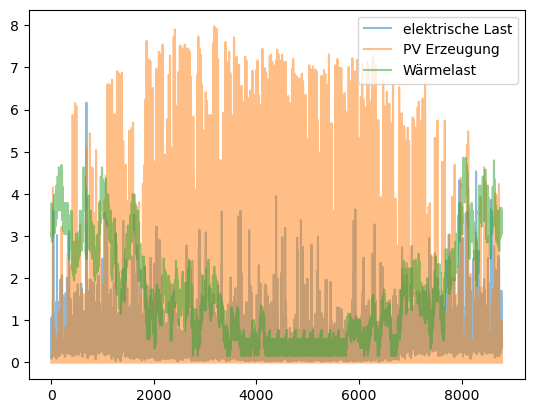

In [3]:
df_data = pd.read_csv('data_Pyomo_3.csv')
df_data.plot(alpha=0.5)

Bauen Sie ein Modell auf, welches die Problemstellung OHNE Heizstab abbildet

In [79]:
model = pyo.ConcreteModel(name='Eigenheim-Energiesystem')
model.T = pyo.Set(initialize = range(0, len(df_data)))

#Parameter
model.par_gaspreis = pyo.Param(initialize = 0.123, doc = 'Gaspreis in €/kWh')
model.par_strompreis = pyo.Param(initialize = 0.409, doc = 'Strompreis in €/kWh')
model.par_gaskessel_max_p = pyo.Param(initialize = 10, doc = 'Maximale Leistung des Gaskessels in kW')
model.par_gaskessel_effizienz = pyo.Param(initialize = 0.99, doc = 'Wirkungsgrad des Gaskessels')
model.par_speicher_max_e = pyo.Param(initialize = 10, doc = 'Maximaler Füllstand des Speicher in kWh')
model.par_speicher_standverluste = pyo.Param(initialize = 0.005, doc = 'Standverluste des Speichers pro Stunde')

model.par_elektrische_last = pyo.Param(model.T, initialize = df_data["elektrische Last"], 
                                       doc = 'Elektrische Last je Stunde in kW')
model.par_heizlast = pyo.Param(model.T, initialize = df_data["Wärmelast"], 
                                       doc = 'Heizlast je Stunde in kW')
model.par_pv_erzeugung = pyo.Param(model.T, initialize = df_data["PV Erzeugung"], 
                                       doc = 'PV Erzeugung je Stunde in kW')
model.par_heizstab_annuitaet = pyo.Param(initialize = 10, doc = 'Annuität in €/a des Heizstabs')
model.par_heizstab_p_nom = pyo.Param(initialize = 0, mutable = True, 
                                     doc = 'Nennleistung des Heizstabs in kW')

#Variablen
model.var_strombezug = pyo.Var(model.T, within = pyo.NonNegativeReals, doc = 'Netzbezug in kW')
model.var_gasnetzbezug = pyo.Var(model.T, within = pyo.NonNegativeReals, doc='Gasnetzbezug in kW')
model.var_pv_leistung  = pyo.Var(model.T, within = pyo.NonNegativeReals, doc='PV Leistung in kW')
model.var_speicher_e = pyo.Var(model.T, within = pyo.NonNegativeReals, bounds=(0,model.par_speicher_max_e), 
                             doc='Speicherfuellstand in kWh')
model.var_speicher_p = pyo.Var(model.T, within = pyo.Reals, doc='Leistung des Speichers')
model.var_heizstab_leistung = pyo.Var(model.T, within = pyo.NonNegativeReals, bounds=(0,model.par_heizstab_p_nom), 
                                      doc = 'Leistung des Heizstabs in kW') 

#Zielfunktion
def Zielfunktion(model):
    return sum(model.var_strombezug[t] * model.par_strompreis + 
                model.var_gasnetzbezug[t] * model.par_gaspreis for t in model.T)
model.obj = pyo.Objective(rule = Zielfunktion, sense = pyo.minimize)

#Nebenbedingung
def rule_strom_energiebilanz(model,t):
    return 0 == - model.par_elektrische_last[t] + model.var_strombezug[t] + model.var_pv_leistung[t] - model.var_heizstab_leistung[t]
model.con_strom_energiebilanz = pyo.Constraint(model.T, rule = rule_strom_energiebilanz, doc='elektrische Last muss gedeckt werden')
def rule_therm_energiebilanz(model,t):
        return 0 == - model.par_heizlast[t] + model.var_gasnetzbezug[t] * model.par_gaskessel_effizienz + model.var_heizstab_leistung[t] + model.var_speicher_p[t]
model.con_therm_energiebilanz = pyo.Constraint(model.T, rule = rule_therm_energiebilanz, doc='Heizlast muss gedeckt werden')

#Entladeleistung <= Fuellstand im Zeitpunkt 1
def rule_limit_entladeleistung(model,t):
    return 0 == model.var_speicher_p[0]
model.con_entladeleistung = pyo.Constraint (model.T, rule = rule_limit_entladeleistung, doc='Entladeleistung darf nicht größer des Füllstandes vor dem ersten Zeitschritt sein')

def rule_fuellstand(model,t):
    if t == 0:
        return model.var_speicher_e[t] == 0
    return model.var_speicher_e[t] == model.var_speicher_e[t-1] * (1-model.par_speicher_standverluste) - model.var_speicher_p[t]
model.con_fuellstand = pyo.Constraint(model.T, rule = rule_fuellstand, doc = 'Fuellstand des thermischen Speichers')

    #PV-Leistung darf PV-Erzeugung nicht übersteigen
def rule_pv_limit(model,t):
    return model.var_pv_leistung[t] <= model.par_pv_erzeugung[t]
model.con_pv_limit = pyo.Constraint (model.T, rule = rule_pv_limit, doc='PV-Leistung darf die maximale Erzeugung nicht übersteigen')

Lösen Sie das Modell

In [80]:
solver = pyo.SolverFactory('cbc')
solver.solve(model)

{'Problem': [{'Name': 'unknown', 'Lower bound': 2844.5307, 'Upper bound': 2844.5307, 'Number of objectives': 1, 'Number of constraints': 43920, 'Number of variables': 52704, 'Number of nonzeros': 8773, 'Sense': 'minimize'}], 'Solver': [{'Status': 'ok', 'User time': -1.0, 'System time': 0.89, 'Wallclock time': 1.12, 'Termination condition': 'optimal', 'Termination message': 'Model was solved to optimality (subject to tolerances), and an optimal solution is available.', 'Statistics': {'Branch and bound': {'Number of bounded subproblems': None, 'Number of created subproblems': None}, 'Black box': {'Number of iterations': 17393}}, 'Error rc': 0, 'Time': 1.1918084621429443}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

Lassen Sie sich die Kosten ausgeben und speichern Sie diese zur Berechnung der Einsparung mit Heizstab

In [81]:
#Da die Lasten, sowie die PV-Erzeugung vordefiniert sind, können die Betriebskosten ohne Lösung des Modells berechnet werden:
ref_kosten = round(sum((df_data["elektrische Last"] - df_data["PV Erzeugung"]).clip(lower=0) * 0.409 + df_data["Wärmelast"]/0.99 * 0.123),2)
print("Referenzkosten:",ref_kosten,"€")

kosten_ohne_heizstab = model.obj()
print("Kosten:", round(kosten_ohne_heizstab,2), "€")

Referenzkosten: 2844.53 €
Kosten: 2844.53 €


Fügen Sie nun notwendige Komponenten dem Modell hinzu und passen Sie ggf. bereits implementierte an, um die Funktion des Heizstabs abzubilden

In [82]:
model.par_heizstab_p_nom  = 3

In [83]:
solver = pyo.SolverFactory('cbc')
solver.solve(model)

{'Problem': [{'Name': 'unknown', 'Lower bound': 2278.50799, 'Upper bound': 2278.50799, 'Number of objectives': 1, 'Number of constraints': 43920, 'Number of variables': 52704, 'Number of nonzeros': 10582, 'Sense': 'minimize'}], 'Solver': [{'Status': 'ok', 'User time': -1.0, 'System time': 0.91, 'Wallclock time': 1.05, 'Termination condition': 'optimal', 'Termination message': 'Model was solved to optimality (subject to tolerances), and an optimal solution is available.', 'Statistics': {'Branch and bound': {'Number of bounded subproblems': None, 'Number of created subproblems': None}, 'Black box': {'Number of iterations': 13684}}, 'Error rc': 0, 'Time': 1.071854591369629}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

Geben Sie sich die Kosten des System mit Sektorenkopplung aus und berechnen Sie die Einsparung, sowie die Amortisationszeit des Heizstabs

In [84]:
ersparnis = round(kosten_ohne_heizstab - model.obj(),2)
print("Kosten:", round(model.obj(),2), "€")
print("Erspranis:", ersparnis, "€")
print("Amortisationszeit:", round(pyo.value(model.par_heizstab_p_nom)*pyo.value(model.par_heizstab_annuitaet)*30/ersparnis,2), "Jahre")

Kosten: 2278.51 €
Erspranis: 566.02 €
Amortisationszeit: 1.59 Jahre


Erstellen Sie ein Ergebnis-Dataframes bestehend aus den zeitabhängigen Variablen

In [85]:
# Vorbereiteter Datenrahmen
ergebnisse = []

# Schleife über die Zeitperioden und extrahiere die Werte
for i in model.T:
    ergebnisse.append({
        'Stromnetzbezug': pyo.value(model.var_strombezug [i]),
        'Gasnetzbezug': pyo.value(model.var_gasnetzbezug[i]),
        'PV-Leistung': pyo.value(model.var_pv_leistung[i]),
        'Heizstab-Leistung': pyo.value(model.var_heizstab_leistung[i]),
        'Speicher-e': pyo.value(model.var_speicher_e[i]),
        'Speicher-p': pyo.value(model.var_speicher_p[i])
        
    })

# Erstelle ein Pandas DataFrame
df = pd.DataFrame(ergebnisse)

Lassen Sie sich zwei Tage grafisch darstellen und diskutieren Sie das Verhalten der Komponenten

<Axes: >

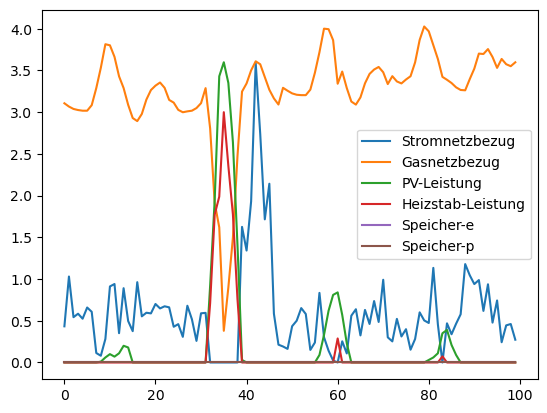

In [86]:
df[0:100].plot()